In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import f1_score, classification_report
from sklearn.utils.class_weight import compute_class_weight
from xgboost import XGBClassifier
import optuna

In [3]:
df = pd.read_csv("ocean_acidity_preprocessed.csv")
X = df.drop(columns=['acidity_level','acidity_level_encoded'])
y = df['acidity_level_encoded']

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [5]:
classes = np.unique(y_train)
weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train
)

class_weights = dict(zip(classes, weights))

sample_weights = y_train.map(class_weights)

In [6]:
xgb_model = XGBClassifier(
    objective='multi:softmax',
    num_class=3,
    eval_metric='mlogloss',
    random_state=42
)
xgb_model.fit(X_train, y_train, sample_weight=sample_weights)

y_pred = xgb_model.predict(X_test)

print("Baseline Macro F1:", f1_score(y_test, y_pred, average='macro'))
print(classification_report(y_test, y_pred))

Baseline Macro F1: 0.9960727194328399
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1569
           1       1.00      1.00      1.00     19397
           2       0.99      1.00      1.00      9034

    accuracy                           1.00     30000
   macro avg       1.00      1.00      1.00     30000
weighted avg       1.00      1.00      1.00     30000



In [7]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(
    xgb_model,
    X,
    y,
    cv=skf,
    scoring='f1_macro'
)

print("CV Macro F1 Scores:", cv_scores)
print("Mean CV Macro F1:", cv_scores.mean())

CV Macro F1 Scores: [0.99403999 0.99613651 0.99412449 0.99396589 0.99517901]
Mean CV Macro F1: 0.9946891778966578


In [8]:
def objective(trial):
    params = {
        "objective": "multi:softmax",
        "num_class": 3,
        "eval_metric": "mlogloss",

        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3),

        "max_depth": trial.suggest_int("max_depth", 3, 10),

        "subsample": trial.suggest_float("subsample", 0.6, 1.0),

        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),

        "n_estimators": trial.suggest_int("n_estimators", 100, 500),

        "gamma": trial.suggest_float("gamma", 0, 5),

        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),

        "random_state": 42
    }

    model = XGBClassifier(**params)

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=skf,
        scoring='f1_macro'
    )

    return scores.mean()

In [9]:
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=30)
print("Best Parameters:")
print(study.best_params)
print("Best CV Macro F1:")
print(study.best_value)

[I 2026-03-07 23:54:33,357] A new study created in memory with name: no-name-ce070c10-8d65-40bb-8cd8-570ba3fe4acf
[I 2026-03-07 23:55:16,079] Trial 0 finished with value: 0.9937700722898875 and parameters: {'learning_rate': 0.07916760313174671, 'max_depth': 8, 'subsample': 0.9779641521600733, 'colsample_bytree': 0.6343487208994688, 'n_estimators': 392, 'gamma': 1.8330672673257964, 'min_child_weight': 9}. Best is trial 0 with value: 0.9937700722898875.
[I 2026-03-07 23:55:56,679] Trial 1 finished with value: 0.9925627267953671 and parameters: {'learning_rate': 0.23087227230775328, 'max_depth': 3, 'subsample': 0.6889765283838128, 'colsample_bytree': 0.8799563119150595, 'n_estimators': 342, 'gamma': 4.42976939801515, 'min_child_weight': 2}. Best is trial 0 with value: 0.9937700722898875.
[I 2026-03-07 23:56:32,503] Trial 2 finished with value: 0.9938627568372548 and parameters: {'learning_rate': 0.17415749190909574, 'max_depth': 7, 'subsample': 0.828153594439446, 'colsample_bytree': 0.602

Best Parameters:
{'learning_rate': 0.20000956538534434, 'max_depth': 10, 'subsample': 0.7617285718933369, 'colsample_bytree': 0.80061050943343, 'n_estimators': 148, 'gamma': 1.7170033639364712, 'min_child_weight': 3}
Best CV Macro F1:
0.994634069617615


In [10]:
best_params = study.best_params
final_model = XGBClassifier(
    **best_params,
    objective='multi:softmax',
    num_class=3,
    eval_metric='mlogloss',
    random_state=42
)
final_model.fit(X_train, y_train, sample_weight=sample_weights)
y_pred = final_model.predict(X_test)
print("Final Macro F1 Score:", f1_score(y_test, y_pred, average='macro'))
print(classification_report(y_test, y_pred))

Final Macro F1 Score: 0.995792964304556
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1569
           1       1.00      1.00      1.00     19397
           2       0.99      1.00      0.99      9034

    accuracy                           1.00     30000
   macro avg       0.99      1.00      1.00     30000
weighted avg       1.00      1.00      1.00     30000



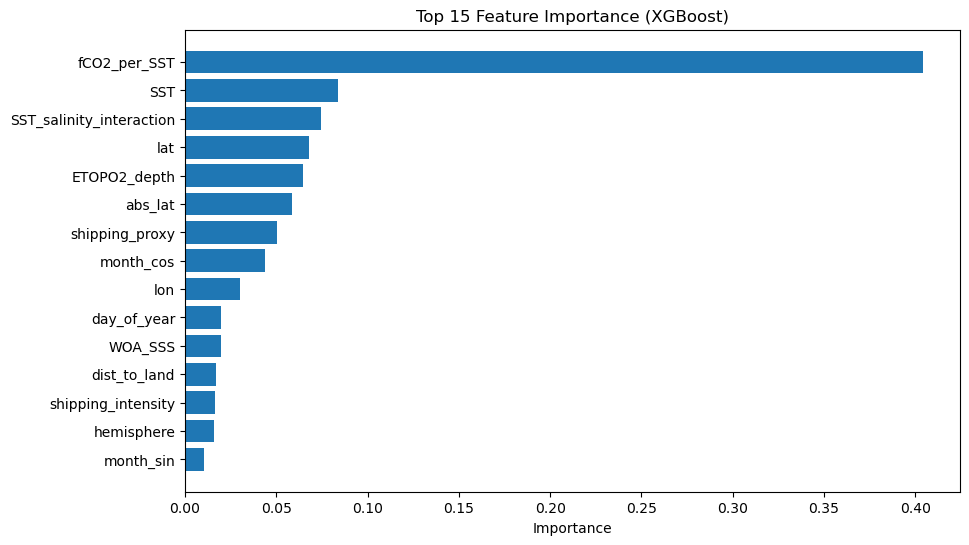

In [13]:
import matplotlib.pyplot as plt
importances = final_model.feature_importances_
feat_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(10,6))
plt.barh(feat_df["Feature"].head(15), feat_df["Importance"].head(15))
plt.gca().invert_yaxis()
plt.title("Top 15 Feature Importance (XGBoost)")
plt.xlabel("Importance")
plt.show()

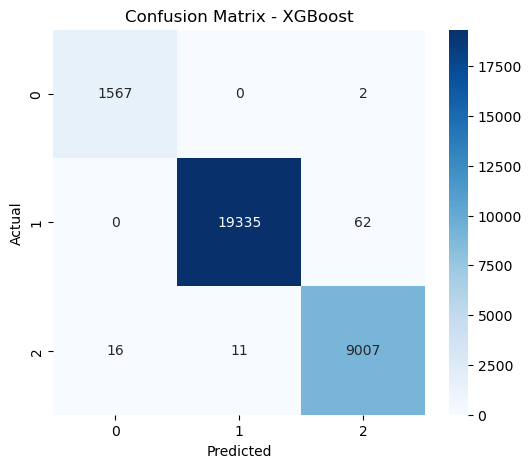

In [12]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - XGBoost")
plt.show()

In [14]:
import joblib
joblib.dump(final_model, "xgboost_acidity_model.pkl")

['xgboost_acidity_model.pkl']